# T01 · OLS 普通最小二乘回归

**论文复现** · EmpirLab traditional 系列

以 **Mincer (1974)** 工资方程为例，完整演示 OLS 实证链路。

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **标题** | *Schooling, Experience, and Earnings* |
| **作者** | Jacob Mincer |
| **出版** | Columbia University Press, 1974 |
| **核心问题** | 教育年限和工作经验对工资的因果效应？ |
| **方法** | OLS（含二次项）+ 稳健标准误 |

## 1. 研究设计

**Mincer 方程**：
$$\ln w_i = \beta_0 + \beta_1 \text{educ}_i + \beta_2 \text{exper}_i+ \beta_3 \text{exper}_i^2 + \varepsilon_i$$

## 2. 数学理论

OLS：$\hat{\beta} = (X'X)^{-1}X'y$

HC1 稳健 SE：$\widehat{\text{Var}}(\hat{\beta}) = (X'X)^{-1}\left(\sum_i \hat{e}_i^2 x_i x_i'\right)(X'X)^{-1}$

## 3. 数据加载与预处理

In [1]:
import sys, io
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

def _set_cjk_font():
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC','Heiti SC',
               'STHeiti','WenQuanYi Micro Hei','Noto Sans CJK SC','Arial Unicode MS']:
        if _f in {f.name for f in _fm.fontManager.ttflist}:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return
    matplotlib.rcParams['axes.unicode_minus'] = False

_set_cjk_font()

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.ols import OLS, mincer_data
from empirlab.utils.visualization import plot_actual_vs_pred

df = mincer_data(n=500, seed=42)
print(f'样本量：{len(df)}')
print(df.describe().round(3))


样本量：500
          educ    exper    exper2  ln_wage     wage
count  500.000  500.000   500.000  500.000  500.000
mean    12.498   19.760   526.212    2.601   15.309
std      3.979   11.663   467.489    0.511    8.054
min      6.000    0.000     0.000    1.096    2.992
25%      9.000    9.000    81.000    2.267    9.653
50%     12.000   20.000   400.000    2.585   13.263
75%     16.000   30.000   900.000    2.976   19.617
max     19.000   39.000  1521.000    3.960   52.435


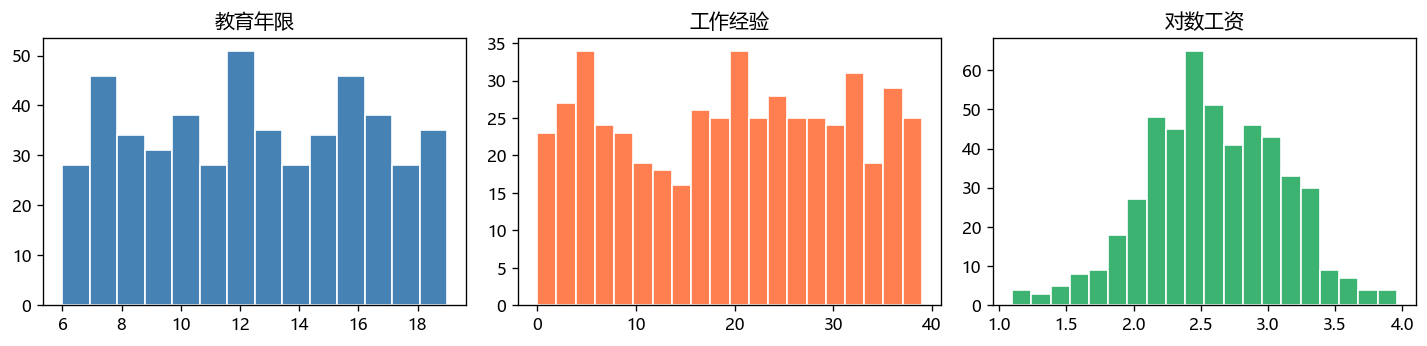

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(df['educ'], bins=14, edgecolor='white', color='steelblue')
axes[0].set_title('教育年限')
axes[1].hist(df['exper'], bins=20, edgecolor='white', color='coral')
axes[1].set_title('工作经验')
axes[2].hist(df['ln_wage'], bins=20, edgecolor='white', color='mediumseagreen')
axes[2].set_title('对数工资')
plt.tight_layout()
show(fig)


## 4. 模型估计

In [3]:
X = df[['educ', 'exper', 'exper2']]
y = df['ln_wage']

model_ols = OLS(fit_intercept=True, robust=False).fit(X, y)
tbl_ols = model_ols.summary_table()
print('=== 基准 OLS ===')
print(tbl_ols.round(4))
fit = model_ols.summary()['fit']
print(f'R²={fit["R2"]:.4f}  adj-R²={fit["adj_R2"]:.4f}  F={fit["F_stat"]:.2f}  p={fit["F_pval"]:.4f}')


=== 基准 OLS ===
             coef      se        t  p_value  ci_lower  ci_upper
parameter                                                      
const      1.1427  0.0686  16.6457      0.0    1.0078    1.2776
educ       0.0844  0.0040  21.0130      0.0    0.0765    0.0923
exper      0.0401  0.0054   7.4718      0.0    0.0295    0.0506
exper2    -0.0007  0.0001  -5.5315      0.0   -0.0010   -0.0005
R²=0.5152  adj-R²=0.5122  F=175.67  p=0.0000


In [4]:
model_hc1 = OLS(fit_intercept=True, robust=True).fit(X, y)
tbl_hc1 = model_hc1.summary_table()
compare = pd.DataFrame({'coef': tbl_ols['coef'],
                        'SE_OLS': tbl_ols['se'],
                        'SE_HC1': tbl_hc1['se']})
print('OLS vs HC1 SE 对比：'); print(compare.round(4))


OLS vs HC1 SE 对比：
             coef  SE_OLS  SE_HC1
parameter                        
const      1.1427  0.0686  0.0695
educ       0.0844  0.0040  0.0040
exper      0.0401  0.0054  0.0053
exper2    -0.0007  0.0001  0.0001


## 5. 结果解读与稳健性检验

In [5]:
coef = {k: v['coef'] for k,v in model_ols.summary()['coefficients'].items()}
print(f'教育回报率: {coef["educ"]*100:.2f}% per year')
print(f'经验峰値年: {-coef["exper"]/(2*coef["exper2"]):.1f} 年')


教育回报率: 8.44% per year
经验峰値年: 27.1 年


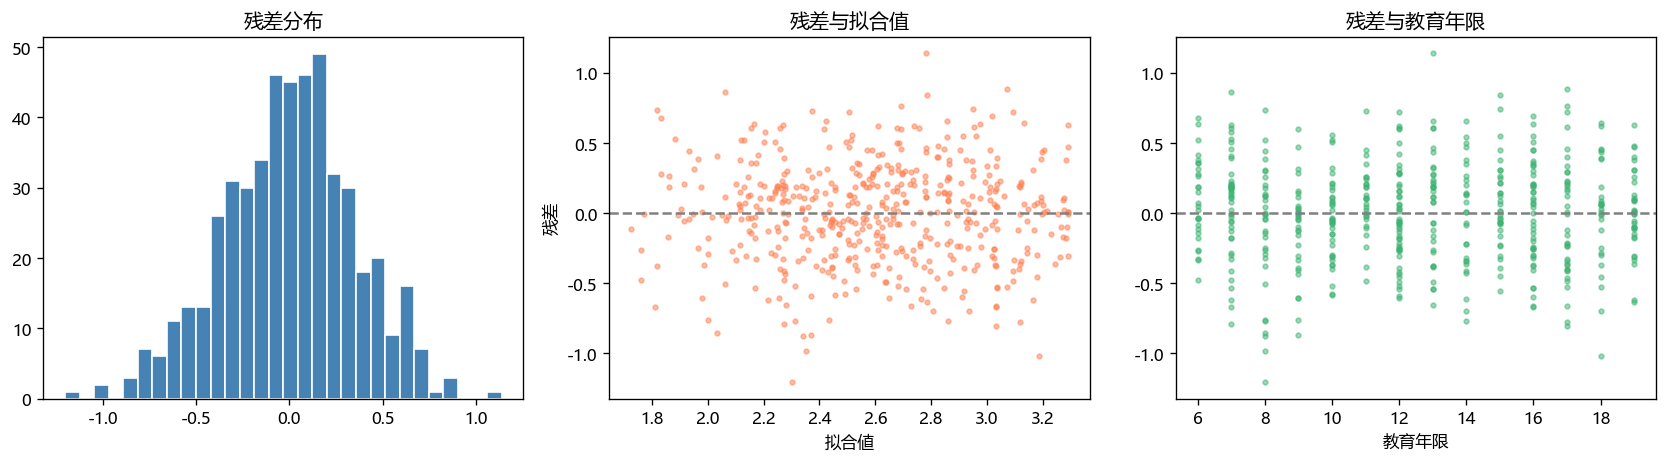

In [6]:
resid = model_ols.residuals()
y_hat = model_ols.predict(X)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(resid, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('残差分布')
axes[1].scatter(y_hat, resid, s=8, alpha=0.5, color='coral')
axes[1].axhline(0, ls='--', c='gray')
axes[1].set_xlabel('拟合値'); axes[1].set_ylabel('残差')
axes[1].set_title('残差与拟合值')
axes[2].scatter(df['educ'], resid, s=8, alpha=0.5, color='mediumseagreen')
axes[2].axhline(0, ls='--', c='gray')
axes[2].set_xlabel('教育年限'); axes[2].set_title('残差与教育年限')
plt.tight_layout()
show(fig)


In [7]:
results = []
for n in [100, 200, 300, 500, 1000]:
    df_n = mincer_data(n=n, seed=0)
    m = OLS(robust=False).fit(df_n[['educ','exper','exper2']], df_n['ln_wage'])
    results.append({'n': n,
                    'educ_coef': round(m.coef_[0],4),
                    'R2': round(m.summary()['fit']['R2'],4)})
print(pd.DataFrame(results).to_string(index=False))


   n  educ_coef     R2
 100     0.0731 0.4661
 200     0.0925 0.6097
 300     0.0839 0.5692
 500     0.0881 0.5945
1000     0.0814 0.4981


## 6. 可视化

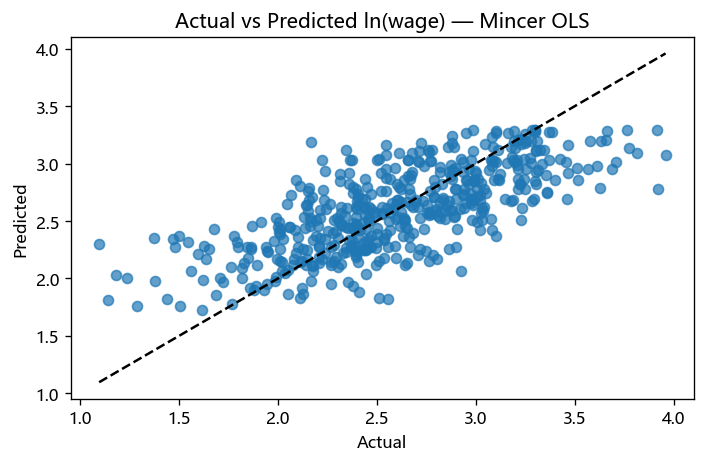

In [8]:
fig, ax = plot_actual_vs_pred(y, model_ols.predict(X))
ax.set_title('Actual vs Predicted ln(wage) — Mincer OLS')
plt.tight_layout()
show(fig)


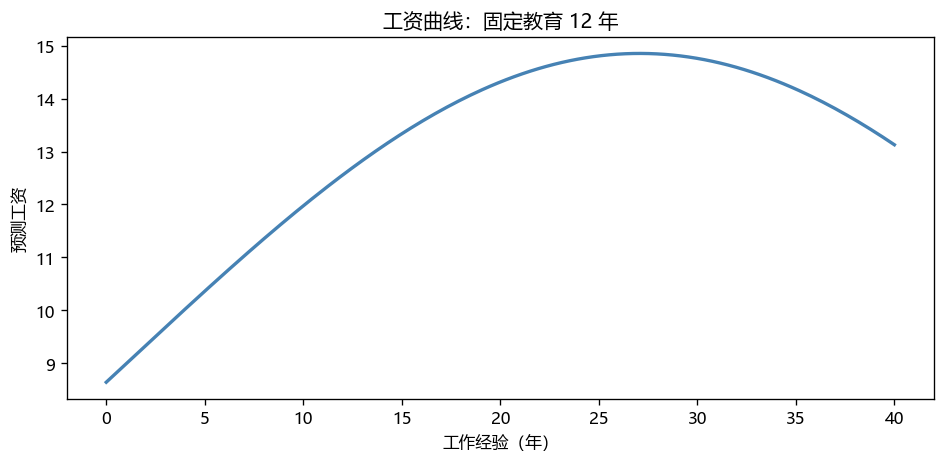

In [9]:
exper_grid = np.linspace(0, 40, 200)
educ_fixed = 12
X_grid = pd.DataFrame({'educ': educ_fixed,
                       'exper': exper_grid,
                       'exper2': exper_grid**2})
wage_pred = np.exp(model_ols.predict(X_grid))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(exper_grid, wage_pred, lw=2, color='steelblue')
ax.set_xlabel('工作经验（年）'); ax.set_ylabel('预测工资')
ax.set_title(f'工资曲线：固定教育 {educ_fixed} 年')
plt.tight_layout()
show(fig)


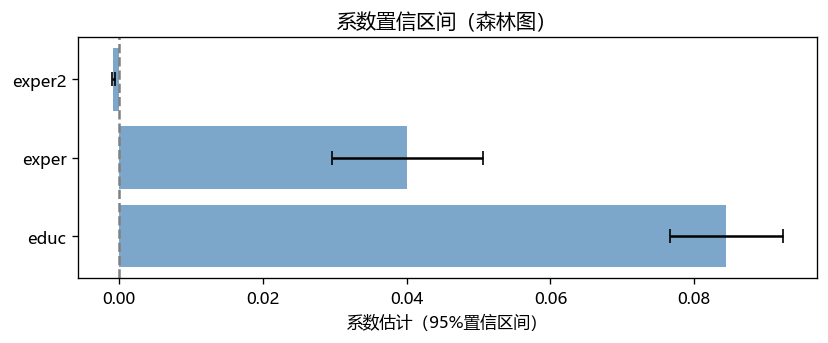

In [10]:
tbl = model_ols.summary_table().drop('const')
fig, ax = plt.subplots(figsize=(7, 3))
y_pos = range(len(tbl))
cv = 1.96 * tbl['se']
ax.barh(list(y_pos), tbl['coef'], xerr=cv,
        color='steelblue', alpha=0.7, capsize=4,
        error_kw={'elinewidth':1.5})
ax.axvline(0, ls='--', c='gray')
ax.set_yticks(list(y_pos)); ax.set_yticklabels(tbl.index.tolist())
ax.set_xlabel('系数估计（95%置信区间）')
ax.set_title('系数置信区间（森林图）')
plt.tight_layout()
show(fig)
